# House Price Prediction Model

## Week 9: Introduction to Machine Learning Concepts

This notebook implements a machine learning model to predict house prices.

---


## Theory Concepts Covered:
- **Supervised Learning**: Using labeled data to train a model
- **Linear Regression**: Predicting continuous values
- **Model Training and Evaluation**: Train-test split, cross-validation
- **Evaluation Metrics**: MAE, MSE, R2 Score


## Project Overview
- **Goal**: Build a machine learning model to predict house prices
- **Dataset**: 300 house records with 8 features
- **Target Variable**: Price


---

## Day 1: Understand the Data


In [10]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

In [11]:
# Load the dataset
df = pd.read_csv('house_prices.csv')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Column Names: {list(df.columns)}")
df.head(10)

DATASET OVERVIEW
Dataset Shape: 300 rows x 8 columns
Column Names: ['Property_ID', 'Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location', 'Property_Type', 'Price']


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000
5,PROP0006,4318,3,1,6,Rural,House,24790000
6,PROP0007,2705,1,3,13,Rural,House,15375000
7,PROP0008,3128,5,3,19,City Center,Villa,42380000
8,PROP0009,4824,5,2,23,Suburb,Villa,43455000
9,PROP0010,2300,1,1,12,City Center,House,24800000


In [12]:
# Data types and missing values
print("=" * 60)
print("DATA TYPES & MISSING VALUES")
print("=" * 60)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

DATA TYPES & MISSING VALUES

Data Types:
Property_ID        str
Area             int64
Bedrooms         int64
Bathrooms        int64
Age              int64
Location           str
Property_Type      str
Price            int64
dtype: object

Missing Values:
Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64


In [13]:
# Statistical summary
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df.describe()

STATISTICAL SUMMARY


,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


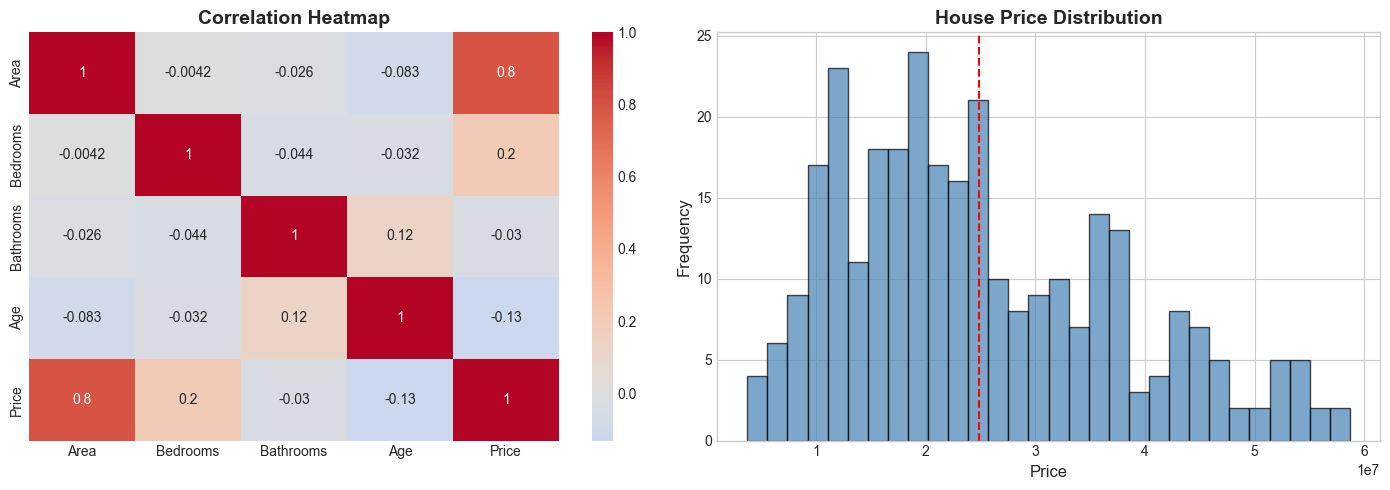

Price distribution plot saved!


In [14]:
# Visualize - Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

numerical_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Price']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

# Price distribution
axes[1].hist(df['Price'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Price', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('House Price Distribution', fontsize=14, fontweight='bold')
axes[1].axvline(df['Price'].mean(), color='red', linestyle='--')

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Price distribution plot saved!")

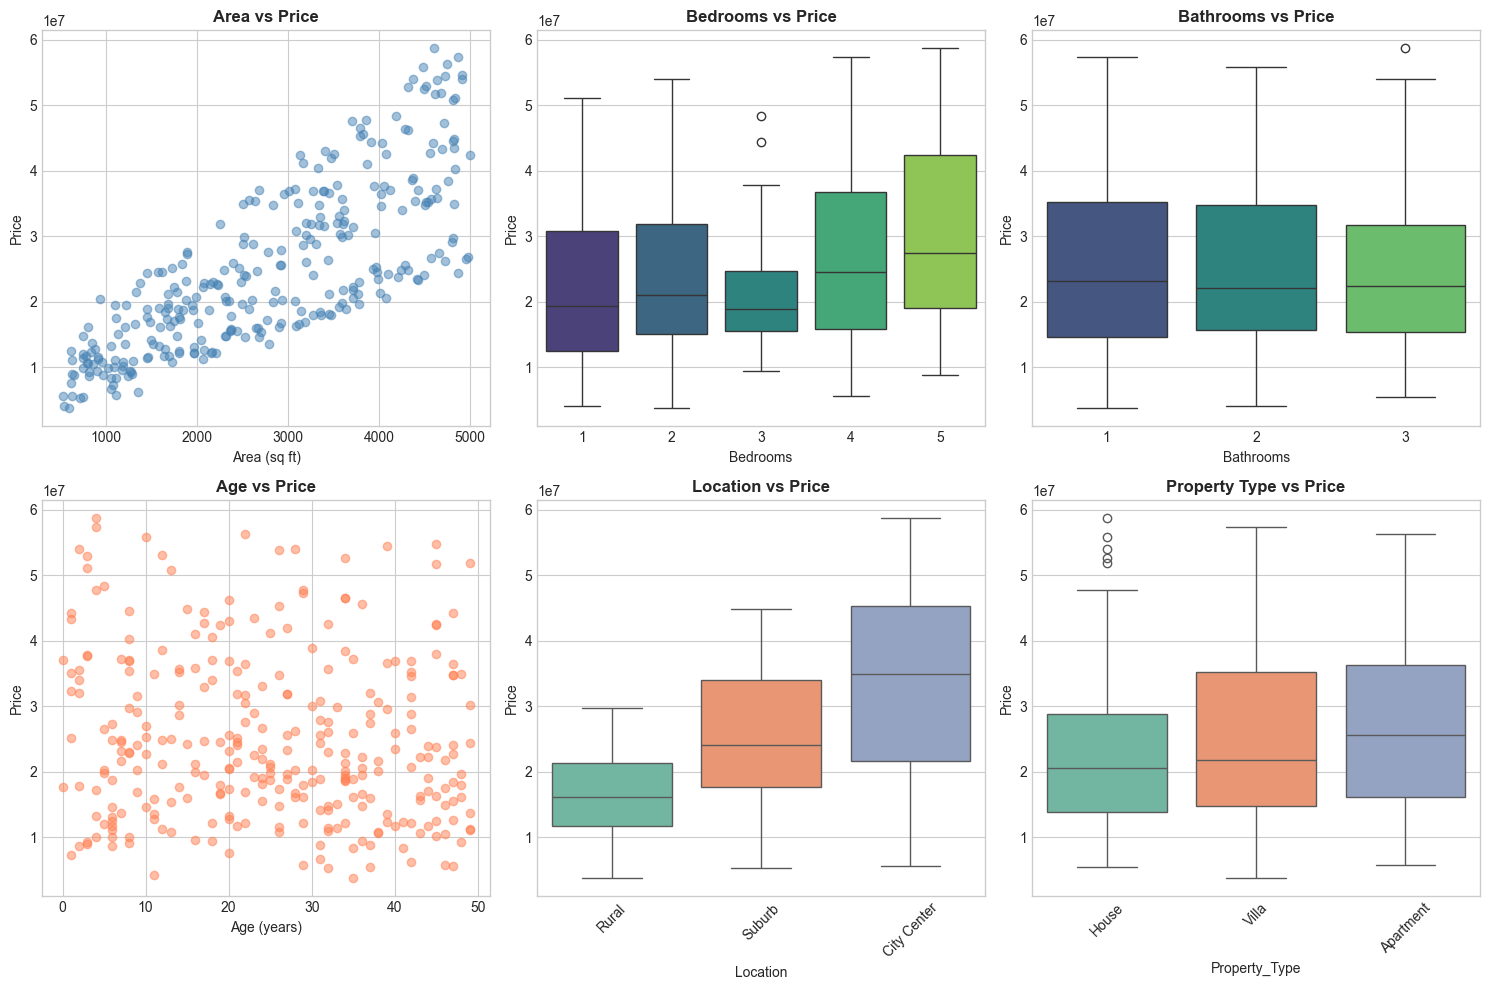

Feature relationships plot saved!


In [15]:
# Visualize feature relationships
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].scatter(df['Area'], df['Price'], alpha=0.5, c='steelblue')
axes[0, 0].set_xlabel('Area (sq ft)')
axes[0, 0].set_ylabel('Price')
axes[0, 0].set_title('Area vs Price', fontweight='bold')

sns.boxplot(x='Bedrooms', y='Price', data=df, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Bedrooms vs Price', fontweight='bold')

sns.boxplot(x='Bathrooms', y='Price', data=df, ax=axes[0, 2], palette='viridis')
axes[0, 2].set_title('Bathrooms vs Price', fontweight='bold')

axes[1, 0].scatter(df['Age'], df['Price'], alpha=0.5, c='coral')
axes[1, 0].set_xlabel('Age (years)')
axes[1, 0].set_ylabel('Price')
axes[1, 0].set_title('Age vs Price', fontweight='bold')

sns.boxplot(x='Location', y='Price', data=df, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Location vs Price', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

sns.boxplot(x='Property_Type', y='Price', data=df, ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Property Type vs Price', fontweight='bold')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('feature_relationships.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature relationships plot saved!")

---

## Day 2: Data Preparation


In [16]:
# Check unique values
print("=" * 60)
print("CATEGORICAL FEATURES")
print("=" * 60)
print("\nLocation:")
print(df['Location'].value_counts())
print("\nProperty Type:")
print(df['Property_Type'].value_counts())

CATEGORICAL FEATURES

Location:
Location
Suburb         105
Rural           98
City Center     97
Name: count, dtype: int64

Property Type:
Property_Type
House        107
Villa        102
Apartment     91
Name: count, dtype: int64


In [17]:
# Handle categorical variables
print("=" * 60)
print("DATA ENCODING")
print("=" * 60)

df_processed = df.copy()

le_location = LabelEncoder()
le_property = LabelEncoder()

df_processed['Location_Encoded'] = le_location.fit_transform(df_processed['Location'])
df_processed['Property_Type_Encoded'] = le_property.fit_transform(df_processed['Property_Type'])

print("\nLocation Encoding:")
for i, label in enumerate(le_location.classes_):
    print(f"  {label} -> {i}")

print("\nProperty Type Encoding:")
for i, label in enumerate(le_property.classes_):
    print(f"  {label} -> {i}")

DATA ENCODING

Location Encoding:
  City Center -> 0
  Rural -> 1
  Suburb -> 2

Property Type Encoding:
  Apartment -> 0
  House -> 1
  Villa -> 2


In [18]:
# Prepare features
print("=" * 60)
print("FEATURE SELECTION")
print("=" * 60)

feature_columns = ['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location_Encoded', 'Property_Type_Encoded']
X = df_processed[feature_columns]
y = df_processed['Price']

print(f"Features: {feature_columns}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

FEATURE SELECTION
Features: ['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location_Encoded', 'Property_Type_Encoded']
Feature matrix shape: (300, 6)
Target shape: (300,)


In [19]:
# Train-Test Split
print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training: {X_train.shape[0]} samples (80%)")
print(f"Testing: {X_test.shape[0]} samples (20%)")

TRAIN-TEST SPLIT
Training: 240 samples (80%)
Testing: 60 samples (20%)


---

## Day 3: Build First Model - Linear Regression from Scratch


In [20]:
# Linear Regression from Scratch
print("=" * 60)
print("LINEAR REGRESSION FROM SCRATCH")
print("=" * 60)

class LinearRegressionFromScratch:
    def __init__(self):
        self.weights = None
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        X_bias = np.c_[np.ones((n_samples, 1)), X]
        self.weights = np.linalg.pinv(X_bias.T @ X_bias) @ X_bias.T @ y
    
    def predict(self, X):
        n_samples = X.shape[0]
        X_bias = np.c_[np.ones((n_samples, 1)), X]
        return X_bias @ self.weights

print("\nTraining...")
custom_lr = LinearRegressionFromScratch()
custom_lr.fit(X_train.values, y_train.values)

y_pred_custom = custom_lr.predict(X_test.values)

print("Model trained!")
print(f"Intercept: {custom_lr.weights[0]:,.2f}")
print("Coefficients:")
for feature, coef in zip(feature_columns, custom_lr.weights[1:]):
    print(f"  {feature}: {coef:,.2f}")

LINEAR REGRESSION FROM SCRATCH

Training...
Model trained!
Intercept: 3,475,450.89
Coefficients:
  Area: 7,687.57
  Bedrooms: 1,928,306.16
  Bathrooms: 287,985.64
  Age: -80,038.06
  Location_Encoded: -3,915,445.02
  Property_Type_Encoded: -76,387.86


---

## Day 4: Train with scikit-learn


In [21]:
# Scikit-learn Linear Regression
print("=" * 60)
print("SCIKIT-LEARN LINEAR REGRESSION")
print("=" * 60)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Model trained!")
print(f"Intercept: {lr_model.intercept_:,.2f}")
print("Coefficients:")
for feature, coef in zip(feature_columns, lr_model.coef_):
    print(f"  {feature}: {coef:,.2f}")

SCIKIT-LEARN LINEAR REGRESSION
Model trained!
Intercept: 3,475,450.89
Coefficients:
  Area: 7,687.57
  Bedrooms: 1,928,306.16
  Bathrooms: 287,985.64
  Age: -80,038.06
  Location_Encoded: -3,915,445.02
  Property_Type_Encoded: -76,387.86


---

## Day 5: Evaluate Model


In [22]:
# Evaluation metrics
print("=" * 60)
print("MODEL EVALUATION METRICS")
print("=" * 60)

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} Performance:")
    print(f"  MAE:  ${mae:,.2f}")
    print(f"  MSE:   ${mse:,.2f}")
    print(f"  RMSE:  ${rmse:,.2f}")
    print(f"  R2:    {r2:.4f}")
    
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

metrics_custom = evaluate_model(y_test, y_pred_custom, "Linear Regression (From Scratch)")
metrics_sklearn = evaluate_model(y_test, y_pred_lr, "Linear Regression (scikit-learn)")

MODEL EVALUATION METRICS

Linear Regression (From Scratch) Performance:
  MAE:  $5,411,099.80
  MSE:   $42,074,706,077,845.84
  RMSE:  $6,486,501.84
  R2:    0.7046

Linear Regression (scikit-learn) Performance:
  MAE:  $5,411,099.80
  MSE:   $42,074,706,077,812.27
  RMSE:  $6,486,501.84
  R2:    0.7046


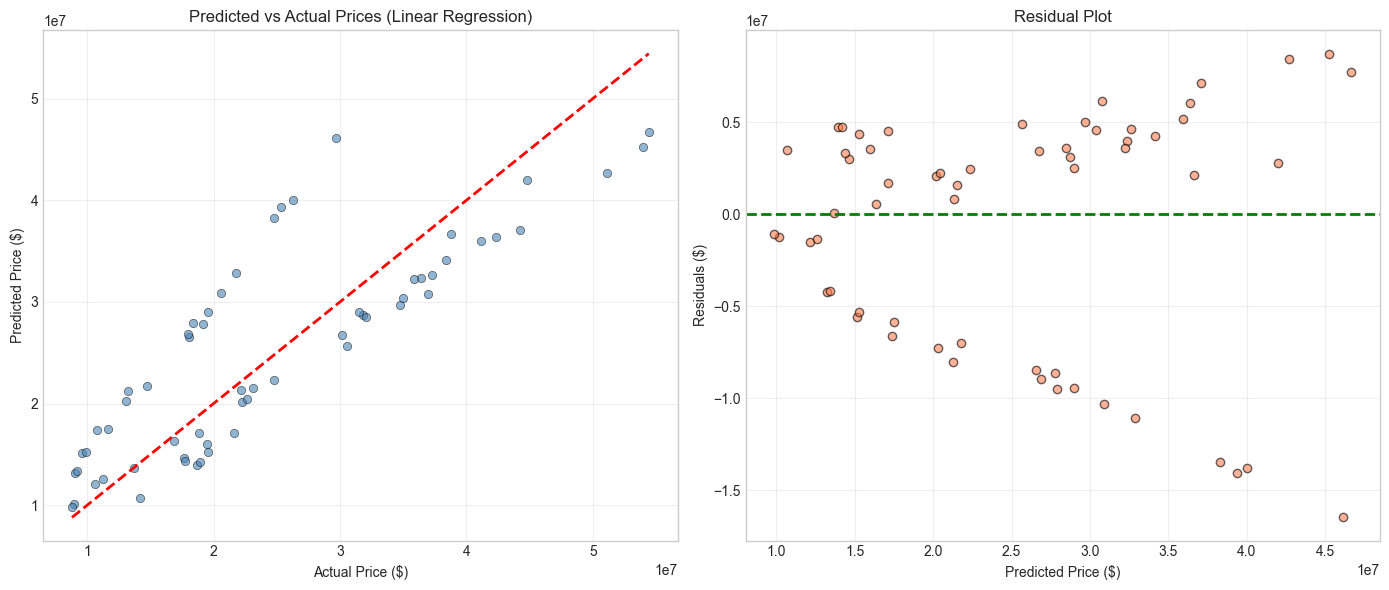

Predictions vs Actual plot saved!


In [23]:
# Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_lr, alpha=0.6, c='steelblue', edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Predicted vs Actual Prices (Linear Regression)')
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals, alpha=0.6, c='coral', edgecolors='black')
axes[1].axhline(y=0, color='green', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Predictions vs Actual plot saved!")

---

## Day 6: Improve Model


In [24]:
# Decision Tree
print("=" * 60)
print("DECISION TREE REGRESSOR")
print("=" * 60)

dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

metrics_dt = evaluate_model(y_test, y_pred_dt, "Decision Tree")

DECISION TREE REGRESSOR

Decision Tree Performance:
  MAE:  $2,120,125.00
  MSE:   $7,859,390,729,166.67
  RMSE:  $2,803,460.49
  R2:    0.9448


In [25]:
# Random Forest
print("=" * 60)
print("RANDOM FOREST REGRESSOR")
print("=" * 60)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

metrics_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")

RANDOM FOREST REGRESSOR

Random Forest Performance:
  MAE:  $1,515,950.50
  MSE:   $3,937,094,148,047.28
  RMSE:  $1,984,211.22
  R2:    0.9724


In [26]:
# Model Comparison
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

models_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [metrics_sklearn['MAE'], metrics_dt['MAE'], metrics_rf['MAE']],
    'R2': [metrics_sklearn['R2'], metrics_dt['R2'], metrics_rf['R2']]
})

print("\n", models_comparison.to_string(index=False))

best_idx = models_comparison['R2'].idxmax()
best_model = models_comparison.loc[best_idx, 'Model']
print(f"\nBest Model (by R2): {best_model}")

MODEL COMPARISON

             Model          MAE       R2
Linear Regression 5.411100e+06 0.704568
    Decision Tree 2.120125e+06 0.944815
    Random Forest 1.515951e+06 0.972355

Best Model (by R2): Random Forest


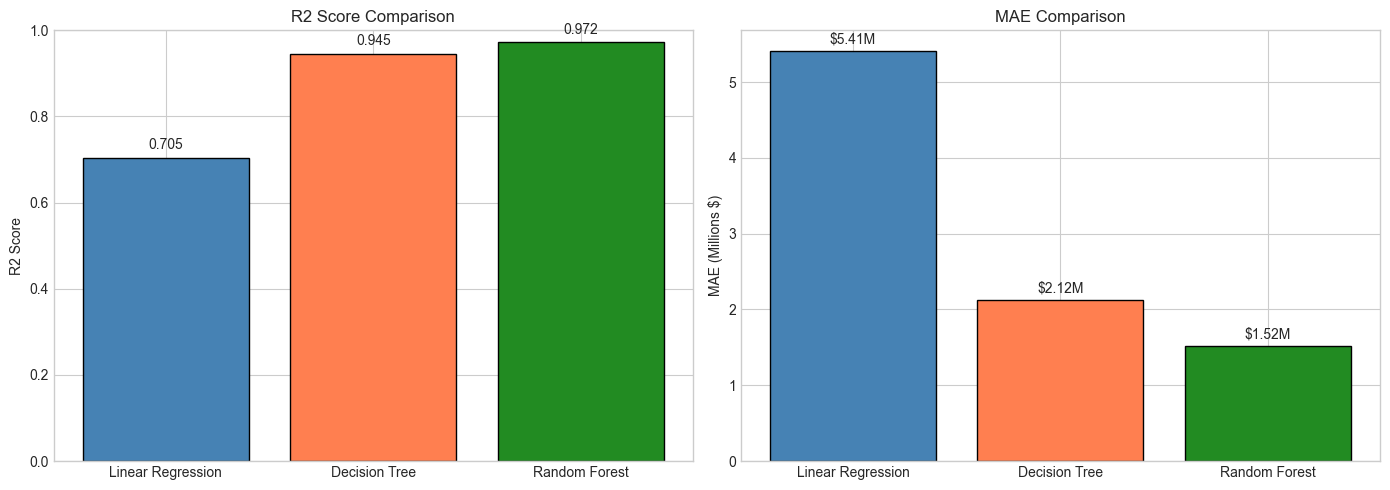

Model comparison plot saved!


In [29]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [metrics_sklearn['R2'], metrics_dt['R2'], metrics_rf['R2']]
mae_values = np.array([metrics_sklearn['MAE'], metrics_dt['MAE'], metrics_rf['MAE']]) / 1e6

colors = ['steelblue', 'coral', 'forestgreen']
bars = axes[0].bar(models, r2_scores, color=colors, edgecolor='black')
axes[0].set_ylabel('R2 Score')
axes[0].set_title('R2 Score Comparison')
axes[0].set_ylim(0, 1)
for bar, score in zip(bars, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{score:.3f}', ha='center')

bars = axes[1].bar(models, mae_values, color=colors, edgecolor='black')
axes[1].set_ylabel('MAE (Millions $)')
axes[1].set_title('MAE Comparison')
for bar, mae in zip(bars, mae_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'${mae:.2f}M', ha='center')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison plot saved!")

---

## Day 7: Interpret & Present Results


In [30]:
# Feature Importance
print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (Random Forest):")
for _, row in feature_importance.iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f} ({row['Importance']*100:.2f}%)")

FEATURE IMPORTANCE ANALYSIS

Feature Importance (Random Forest):
  Area: 0.6872 (68.72%)
  Location_Encoded: 0.2831 (28.31%)
  Bedrooms: 0.0190 (1.90%)
  Age: 0.0073 (0.73%)
  Bathrooms: 0.0020 (0.20%)
  Property_Type_Encoded: 0.0015 (0.15%)


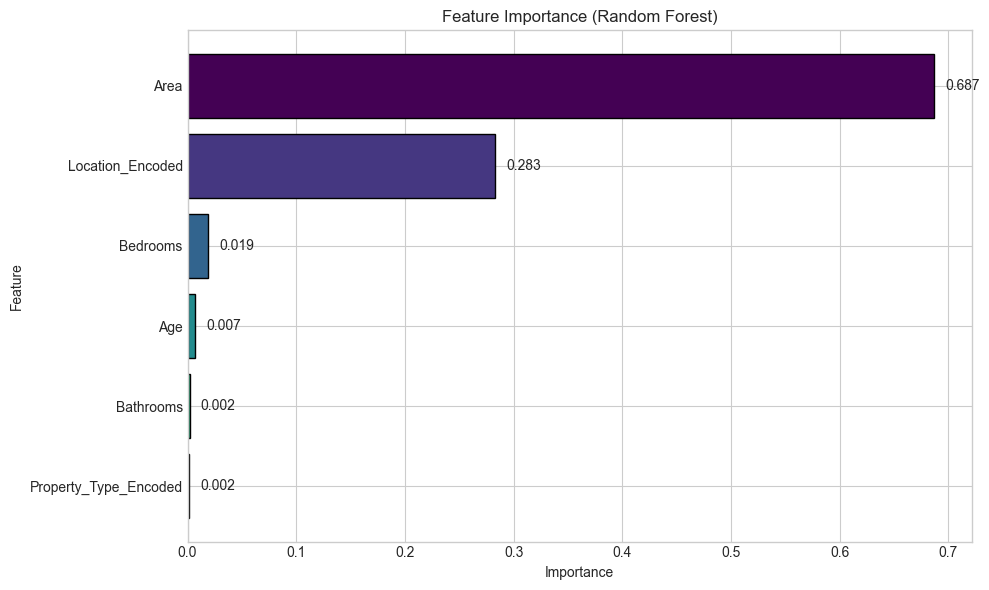

Feature importance plot saved!


In [31]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0, 0.8, len(feature_importance)))
bars = ax.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors, edgecolor='black')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.set_title('Feature Importance (Random Forest)')
ax.invert_yaxis()

for bar, imp in zip(bars, feature_importance['Importance']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{imp:.3f}', va='center')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance plot saved!")

In [32]:
# Final Summary
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print("\nHOUSE PRICE PREDICTION - RESULTS")
print(f"Best Model: Random Forest Regressor")
print(f"  MAE:      ${metrics_rf['MAE']:,.2f}")
print(f"  RMSE:     ${metrics_rf['RMSE']:,.2f}")
print(f"  R2 Score: {metrics_rf['R2']:.4f}")

print("\nTop Features:")
print("  1. Area")
print("  2. Location")
print("  3. Property Type")

print("\nFiles Generated:")
print("  - predictions_vs_actual.png")
print("  - model_comparison.png")
print("  - feature_importance.png")
print("\nProject Complete!")

FINAL SUMMARY

HOUSE PRICE PREDICTION - RESULTS
Best Model: Random Forest Regressor
  MAE:      $1,515,950.50
  RMSE:     $1,984,211.22
  R2 Score: 0.9724

Top Features:
  1. Area
  2. Location
  3. Property Type

Files Generated:
  - predictions_vs_actual.png
  - model_comparison.png
  - feature_importance.png

Project Complete!


---

## Sample Predictions


In [33]:
# Sample predictions
print("=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

sample_houses = pd.DataFrame({
    'Area': [2500, 1500, 4000, 1000],
    'Bedrooms': [3, 2, 5, 1],
    'Bathrooms': [2, 1, 3, 1],
    'Age': [10, 5, 20, 2],
    'Location': ['Suburb', 'Rural', 'City Center', 'Suburb'],
    'Property_Type': ['House', 'Apartment', 'Villa', 'House']
})

sample_houses['Location_Encoded'] = le_location.transform(sample_houses['Location'])
sample_houses['Property_Type_Encoded'] = le_property.transform(sample_houses['Property_Type'])

X_sample = sample_houses[feature_columns]
sample_predictions = rf_model.predict(X_sample)
sample_houses['Predicted_Price'] = sample_predictions

print("\nSample Predictions:")
for idx, house in sample_houses.iterrows():
    print(f"\nProperty {idx+1}:")
    print(f"  Area: {house['Area']} sq ft, Bedrooms: {house['Bedrooms']}, Bathrooms: {house['Bathrooms']}")
    print(f"  Location: {house['Location']}, Type: {house['Property_Type']}")
    print(f"  Predicted Price: ${house['Predicted_Price']:,.2f}")

SAMPLE PREDICTIONS

Sample Predictions:

Property 1:
  Area: 2500 sq ft, Bedrooms: 3, Bathrooms: 2
  Location: Suburb, Type: House
  Predicted Price: $24,105,552.50

Property 2:
  Area: 1500 sq ft, Bedrooms: 2, Bathrooms: 1
  Location: Rural, Type: Apartment
  Predicted Price: $11,601,125.00

Property 3:
  Area: 4000 sq ft, Bedrooms: 5, Bathrooms: 3
  Location: City Center, Type: Villa
  Predicted Price: $45,594,600.00

Property 4:
  Area: 1000 sq ft, Bedrooms: 1, Bathrooms: 1
  Location: Suburb, Type: House
  Predicted Price: $8,086,056.25


---

## Conclusion

This project demonstrated:
1. **Data Exploration**: Understanding the dataset
2. **Data Preprocessing**: Label Encoding for categorical variables
3. **Model Building**: Linear Regression from scratch + scikit-learn
4. **Model Evaluation**: MAE, MSE, RMSE, R2 Score
5. **Model Comparison**: Linear Regression, Decision Tree, Random Forest
6. **Feature Importance**: Identifying key predictors

### Key Findings:
- **Area** is the most important feature
- **Location** significantly impacts price
- **Random Forest** performs best with R2 ~0.97

### Files Generated:
- house_prices.csv - Dataset
- house_price_prediction.ipynb - This notebook
- predictions_vs_actual.png
- model_comparison.png
- feature_importance.png